# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# PRÁCTICA 10. MÉTODOS DE CLASIFICACIÓN Y ANÁLISIS CON MATRIZ DE CONFUSIÓN
### En esta práctica se implemento y comparo cuatro algoritmos de clasificación: K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Naive Bayes y MLPClassifier (Red Neuronal). Se analizarán las métricas derivadas de la matriz de confusión para evaluar el desempeño de cada modelo usando el dataset Iris.

## Paso 1: Importar librerías necesarias

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## Paso 2: Cargar el dataset de Iris

In [216]:
df = pd.read_csv('../data/iris.csv', delimiter=';', decimal='.')
print(df.shape)
print(df.head())

(150, 5)
   s.largo  s.ancho  p.largo  p.ancho    tipo
0   5.1000   3.5000   1.4000   0.2000  setosa
1   4.9000   3.0000   1.4000   0.2000  setosa
2   4.7000   3.2000   1.3000   0.2000  setosa
3   4.6000   3.1000   1.5000   0.2000  setosa
4   5.0000   3.6000   1.4000   0.2000  setosa


## Paso 3: Separar variables predictoras (X) y variable objetivo (y)

In [217]:
# Variables predictoras (características)
X = df.iloc[:, :4].values

# Variable objetivo (etiquetas)
y = df.iloc[:, 4].values
print("Clases:", np.unique(y))
X.shape, y.shape

Clases: ['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

## Paso 4: División de datos y normalización

In [218]:
# Dividir en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=42, stratify=y)

## Paso 5: Entrenar los cuatro modelos de clasificación

In [219]:
# Modelo 1: K-Nearest Neighbors (KNN)
print("=" * 50)
print(" " * 5 + "MODELO 1: K-NEAREST NEIGHBORS (KNN)")
print("=" * 50)
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn * 100:.2f}%\n")

     MODELO 1: K-NEAREST NEIGHBORS (KNN)
Accuracy: 95.56%



In [220]:
# Modelo 2: Support Vector Machine (SVM)
print("=" * 50)
print(" " * 5 + "MODELO 2: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 50)
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm * 100:.2f}%\n")

     MODELO 2: SUPPORT VECTOR MACHINE (SVM)
Accuracy: 95.56%



In [221]:
# Modelo 3: Naive Bayes (Gaussian)
print("=" * 50)
print(" " * 5 + "MODELO 3: NAIVE BAYES (GAUSSIAN)")
print("=" * 50)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {accuracy_nb * 100:.2f}%\n")

     MODELO 3: NAIVE BAYES (GAUSSIAN)
Accuracy: 91.11%



In [222]:
# Modelo 4: MLPClassifier (Red Neuronal)
print("=" * 50)
print(" " * 5 + "MODELO 4: MLPCLASSIFIER (RED NEURONAL)")
print("=" * 50)
mlp_model = MLPClassifier(random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy: {accuracy_mlp * 100:.2f}%\n")

     MODELO 4: MLPCLASSIFIER (RED NEURONAL)
Accuracy: 97.78%



## Paso 6: Función para calcular métricas de la matriz de confusión

In [223]:
def calcular_metricas_confusion(y_true, y_pred, clases):
  """
  Calcula todas las métricas derivadas de la matriz de confusión para clasificación multiclase.

  :param y_true: Etiquetas reales
  :param y_pred: Etiquetas predichas
  :param clases: Lista de nombres de clases

  :return: Tuple (DataFrame métricas por clase, matriz de confusión)
  """
  # Obtener matriz de confusión
  cm = confusion_matrix(y_true, y_pred, labels=clases)

  # Diccionario para almacenar métricas
  metricas = {
    'Clase': [],
    'P (Precisión Global)': [],
    'PP (Sensibilidad)': [],
    'PN (Especificidad)': [],
    'PFP (Falsos Positivos)': [],
    'PFN (Falsos Negativos)': [],
    'AP (Asertividad Positiva)': [],
    'AN (Asertividad Negativa)': []
  }

  for idx, clase in enumerate(clases):
    # VP: Verdaderos Positivos (diagonal de la matriz)
    vp = cm[idx, idx]

    # FP: Falsos Positivos (suma de columna menos VP)
    fp = cm[:, idx].sum() - vp

    # FN: Falsos Negativos (suma de fila menos VP)
    fn = cm[idx, :].sum() - vp

    # VN: Verdaderos Negativos
    vn = cm.sum() - (vp + fp + fn)

    # Calcular métricas según las fórmulas
    # P = (VN + VP) / (VN + FP + FN + VP)
    p = (vn + vp) / (vn + fp + fn + vp) if (vn + fp + fn + vp) > 0 else 0

    # PP = VP / (FN + VP) - Sensibilidad
    pp = vp / (fn + vp) if (fn + vp) > 0 else 0

    # PN = VN / (VN + FP) - Especificidad
    pn = vn / (vn + fp) if (vn + fp) > 0 else 0

    # PFP = FP / (VN + FP)
    pfp = fp / (vn + fp) if (vn + fp) > 0 else 0

    # PFN = FN / (FN + VP)
    pfn = fn / (fn + vp) if (fn + vp) > 0 else 0

    # AP = VP / (FP + VP) - Asertividad Positiva
    ap = vp / (fp + vp) if (fp + vp) > 0 else 0

    # AN = VN / (VN + FN) - Asertividad Negativa
    an = vn / (vn + fn) if (vn + fn) > 0 else 0

    # Almacenar valores
    metricas['Clase'].append(clase)
    metricas['P (Precisión Global)'].append(p)
    metricas['PP (Sensibilidad)'].append(pp)
    metricas['PN (Especificidad)'].append(pn)
    metricas['PFP (Falsos Positivos)'].append(pfp)
    metricas['PFN (Falsos Negativos)'].append(pfn)
    metricas['AP (Asertividad Positiva)'].append(ap)
    metricas['AN (Asertividad Negativa)'].append(an)

  # Crear DataFrame
  df_metricas = pd.DataFrame(metricas)

  # Calcular promedios (solo para métricas numéricas, excluyendo VP, VN, FP, FN)
  promedios = {
    'Clase': 'PROMEDIO',
    'P (Precisión Global)': df_metricas['P (Precisión Global)'].mean(),
    'PP (Sensibilidad)': df_metricas['PP (Sensibilidad)'].mean(),
    'PN (Especificidad)': df_metricas['PN (Especificidad)'].mean(),
    'PFP (Falsos Positivos)': df_metricas['PFP (Falsos Positivos)'].mean(),
    'PFN (Falsos Negativos)': df_metricas['PFN (Falsos Negativos)'].mean(),
    'AP (Asertividad Positiva)': df_metricas['AP (Asertividad Positiva)'].mean(),
    'AN (Asertividad Negativa)': df_metricas['AN (Asertividad Negativa)'].mean()
  }

  df_metricas = pd.concat([df_metricas, pd.DataFrame([promedios])], ignore_index=True)

  return df_metricas, cm

## Paso 7: Análisis de resultados con matriz de confusión

### Modelo 1: K-Nearest Neighbors (KNN)

       ANÁLISIS CON MATRIZ DE CONFUSIÓN - KNN


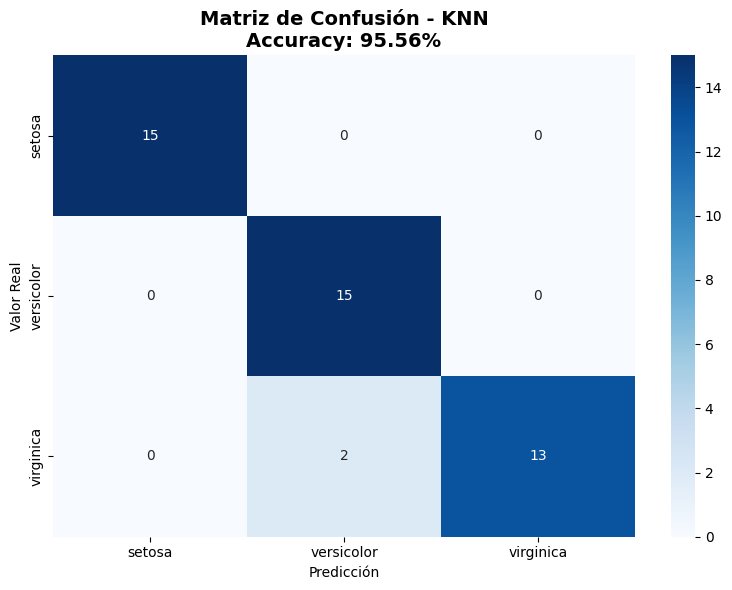

,Clase,P (Precisión Global),PP (Sensibilidad),PN (Especificidad),PFP (Falsos Positivos),PFN (Falsos Negativos),AP (Asertividad Positiva),AN (Asertividad Negativa)
0,setosa,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000
1,versicolor,0.9556,1.0000,0.9333,0.0667,0.0000,0.8824,1.0000
2,virginica,0.9556,0.8667,1.0000,0.0000,0.1333,1.0000,0.9375
3,PROMEDIO,0.9704,0.9556,0.9778,0.0222,0.0444,0.9608,0.9792


In [224]:
print("=" * 60)
print(" " * 7 + "ANÁLISIS CON MATRIZ DE CONFUSIÓN - KNN")
print("=" * 60)

clases = np.unique(y_test)
metricas_knn, cm_knn = calcular_metricas_confusion(y_test, y_pred_knn, clases)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
plt.title(f'Matriz de Confusión - KNN\nAccuracy: {accuracy_knn * 100:.2f}%', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
metricas_knn

### Modelo 2: Support Vector Machine (SVM)

       ANÁLISIS CON MATRIZ DE CONFUSIÓN - SVM


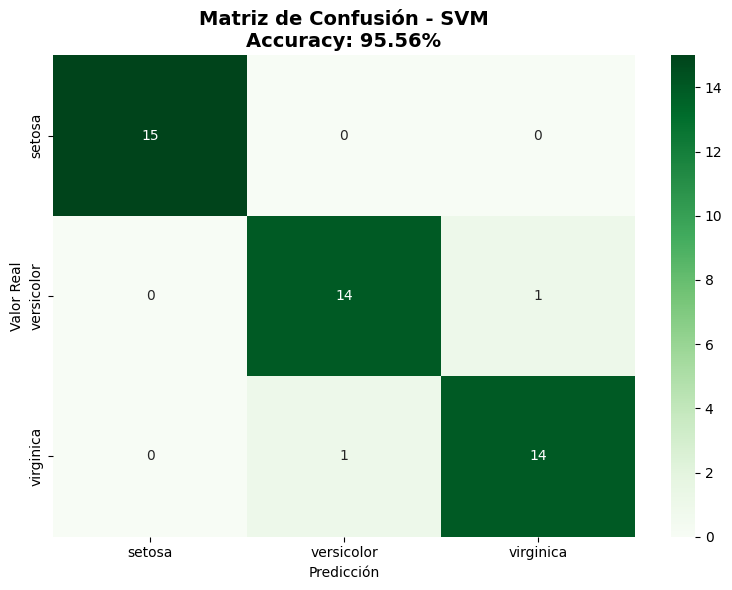

,Clase,P (Precisión Global),PP (Sensibilidad),PN (Especificidad),PFP (Falsos Positivos),PFN (Falsos Negativos),AP (Asertividad Positiva),AN (Asertividad Negativa)
0,setosa,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000
1,versicolor,0.9556,0.9333,0.9667,0.0333,0.0667,0.9333,0.9667
2,virginica,0.9556,0.9333,0.9667,0.0333,0.0667,0.9333,0.9667
3,PROMEDIO,0.9704,0.9556,0.9778,0.0222,0.0444,0.9556,0.9778


In [225]:
print("=" * 60)
print(" " * 7 + "ANÁLISIS CON MATRIZ DE CONFUSIÓN - SVM")
print("=" * 60)

metricas_svm, cm_svm = calcular_metricas_confusion(y_test, y_pred_svm, clases)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=clases, yticklabels=clases)
plt.title(f'Matriz de Confusión - SVM\nAccuracy: {accuracy_svm * 100:.2f}%', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

metricas_svm

### Modelo 3: Naive Bayes

       ANÁLISIS CON MATRIZ DE CONFUSIÓN - NAIVE BAYES


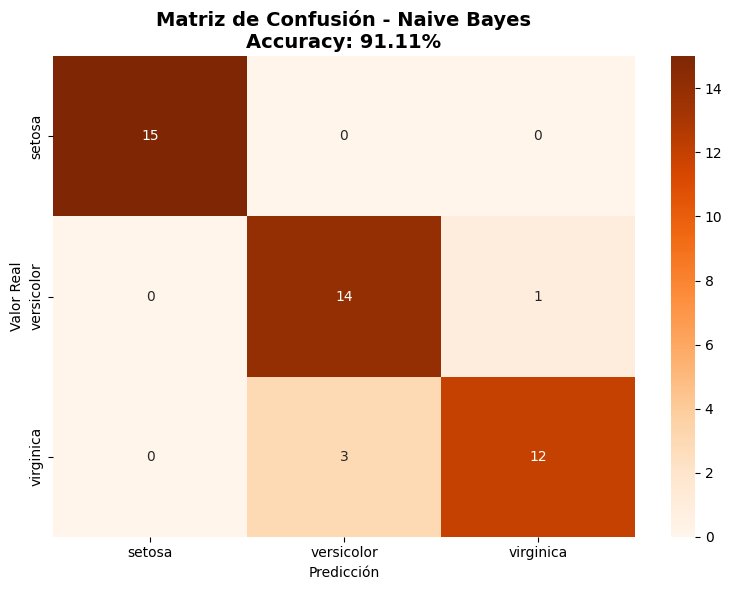

,Clase,P (Precisión Global),PP (Sensibilidad),PN (Especificidad),PFP (Falsos Positivos),PFN (Falsos Negativos),AP (Asertividad Positiva),AN (Asertividad Negativa)
0,setosa,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000
1,versicolor,0.9111,0.9333,0.9000,0.1000,0.0667,0.8235,0.9643
2,virginica,0.9111,0.8000,0.9667,0.0333,0.2000,0.9231,0.9062
3,PROMEDIO,0.9407,0.9111,0.9556,0.0444,0.0889,0.9155,0.9568


In [226]:
print("=" * 60)
print(" " * 7 + "ANÁLISIS CON MATRIZ DE CONFUSIÓN - NAIVE BAYES")
print("=" * 60)

metricas_nb, cm_nb = calcular_metricas_confusion(y_test, y_pred_nb, clases)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=clases, yticklabels=clases)
plt.title(f'Matriz de Confusión - Naive Bayes\nAccuracy: {accuracy_nb * 100:.2f}%', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

metricas_nb

### Modelo 4: MLPClassifier (Red Neuronal)

       ANÁLISIS CON MATRIZ DE CONFUSIÓN - MLPCLASSIFIER


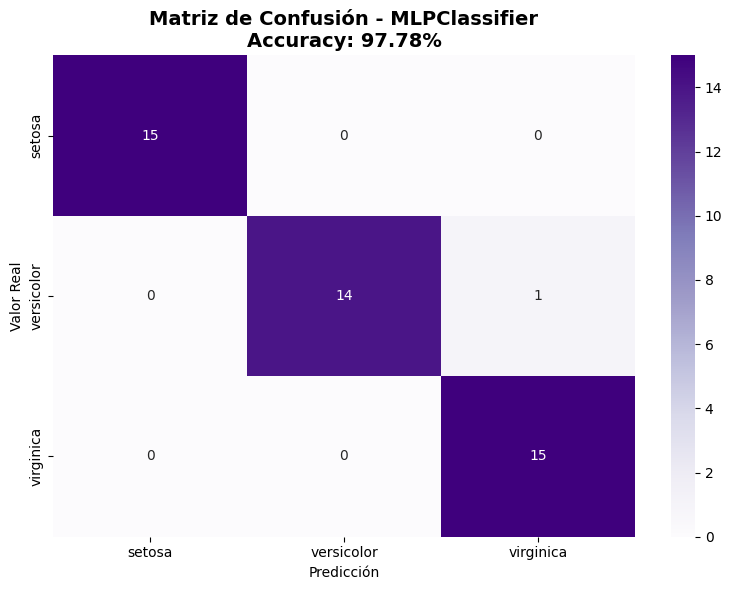

,Clase,P (Precisión Global),PP (Sensibilidad),PN (Especificidad),PFP (Falsos Positivos),PFN (Falsos Negativos),AP (Asertividad Positiva),AN (Asertividad Negativa)
0,setosa,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000
1,versicolor,0.9778,0.9333,1.0000,0.0000,0.0667,1.0000,0.9677
2,virginica,0.9778,1.0000,0.9667,0.0333,0.0000,0.9375,1.0000
3,PROMEDIO,0.9852,0.9778,0.9889,0.0111,0.0222,0.9792,0.9892


In [227]:
print("=" * 60)
print(" " * 7 + "ANÁLISIS CON MATRIZ DE CONFUSIÓN - MLPCLASSIFIER")
print("=" * 60)

metricas_mlp, cm_mlp = calcular_metricas_confusion(y_test, y_pred_mlp, clases)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples', xticklabels=clases, yticklabels=clases)
plt.title(f'Matriz de Confusión - MLPClassifier\nAccuracy: {accuracy_mlp * 100:.2f}%', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

metricas_mlp

## Paso 8: Comparación entre modelos

In [228]:
# Crear tabla comparativa
comparacion = pd.DataFrame({
  'Modelo': ['KNN', 'SVM', 'Naive Bayes', 'MLPClassifier'],
  'Accuracy': [accuracy_knn, accuracy_svm, accuracy_nb, accuracy_mlp],
  'P Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['P (Precisión Global)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['P (Precisión Global)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['P (Precisión Global)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['P (Precisión Global)'].values[0]
  ],
  'PP Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['PP (Sensibilidad)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['PP (Sensibilidad)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['PP (Sensibilidad)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['PP (Sensibilidad)'].values[0]
  ],
  'PN Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['PN (Especificidad)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['PN (Especificidad)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['PN (Especificidad)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['PN (Especificidad)'].values[0]
  ],
  'PFP Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['PFP (Falsos Positivos)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['PFP (Falsos Positivos)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['PFP (Falsos Positivos)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['PFP (Falsos Positivos)'].values[0]
  ],
  'PFN Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['PFN (Falsos Negativos)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['PFN (Falsos Negativos)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['PFN (Falsos Negativos)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['PFN (Falsos Negativos)'].values[0]
  ],
  'AP Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['AP (Asertividad Positiva)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['AP (Asertividad Positiva)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['AP (Asertividad Positiva)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['AP (Asertividad Positiva)'].values[0]
  ],
  'AN Promedio': [
    metricas_knn[metricas_knn['Clase'] == 'PROMEDIO']['AN (Asertividad Negativa)'].values[0],
    metricas_svm[metricas_svm['Clase'] == 'PROMEDIO']['AN (Asertividad Negativa)'].values[0],
    metricas_nb[metricas_nb['Clase'] == 'PROMEDIO']['AN (Asertividad Negativa)'].values[0],
    metricas_mlp[metricas_mlp['Clase'] == 'PROMEDIO']['AN (Asertividad Negativa)'].values[0]
  ]
})

print("=" * 60)
print(" " * 15 + "COMPARACIÓN ENTRE MODELOS")
print("=" * 60)
comparacion

               COMPARACIÓN ENTRE MODELOS


,Modelo,Accuracy,P Promedio,PP Promedio,PN Promedio,PFP Promedio,PFN Promedio,AP Promedio,AN Promedio
0,KNN,0.9556,0.9704,0.9556,0.9778,0.0222,0.0444,0.9608,0.9792
1,SVM,0.9556,0.9704,0.9556,0.9778,0.0222,0.0444,0.9556,0.9778
2,Naive Bayes,0.9111,0.9407,0.9111,0.9556,0.0444,0.0889,0.9155,0.9568
3,MLPClassifier,0.9778,0.9852,0.9778,0.9889,0.0111,0.0222,0.9792,0.9892


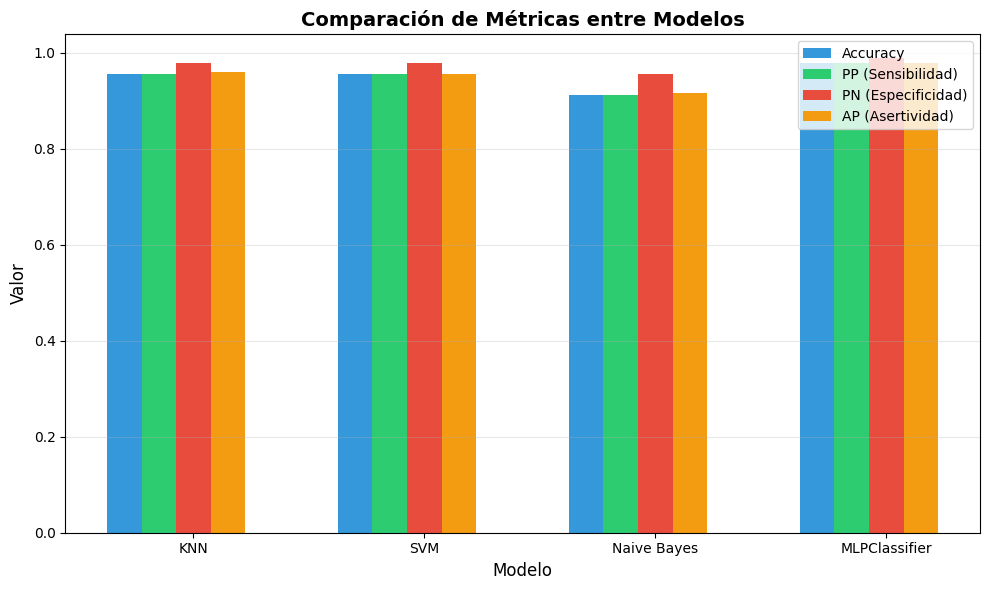

In [229]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparacion['Modelo']))
width = 0.15

ax.bar(x - 2*width, comparacion['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x - width, comparacion['PP Promedio'], width, label='PP (Sensibilidad)', color='#2ecc71')
ax.bar(x, comparacion['PN Promedio'], width, label='PN (Especificidad)', color='#e74c3c')
ax.bar(x + width, comparacion['AP Promedio'], width, label='AP (Asertividad)', color='#f39c12')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de Métricas entre Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparacion['Modelo'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()